<a href="https://colab.research.google.com/github/dositadi/beures_housing/blob/main/Beures_housing_model_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# file name pattern
pattern = "/content/drive/MyDrive/world_quant/phase2/buenos-aires-real-estate-*.csv"

In [3]:
from glob import glob
import pandas as pd
import numpy as np

In [4]:
# write a merged files function that merges all the files in the glob (this is for reusability sake)

def merged_files(pattern: str) -> pd.DataFrame:
  return pd.concat([pd.read_csv(path) for path in glob(pattern)],ignore_index=True)

In [5]:
# write a reusable function to filter and keep only Capital Federal apartments under $400K
def filter_data(dataframe: pd.DataFrame) -> pd.DataFrame:
  return (
      dataframe
      .loc[lambda df: df['place_with_parent_names']
           .str.contains('Capital Federal')]
      .loc[lambda df: df['property_type'] == "apartment"]
      .loc[lambda df: df['price_aprox_usd'] < 400_000]
  )

In [6]:
# write a reusable function to handle the outlier using the quantile based approach
def outlier_df(outlier_data: pd.DataFrame) -> pd.DataFrame:
  return (outlier_data.loc[lambda df: df['surface_covered_in_m2'].between(df['surface_covered_in_m2'].quantile(0.1), df['surface_covered_in_m2'].quantile(0.9))])

In [7]:
# write a reusable function for feature engineering
def modify_col(dataframe: pd.DataFrame) -> pd.DataFrame:
  return (
      dataframe.assign(
          lat = lambda df:
            df['lat-lon'].str.split(',',expand=True)[0].astype(np.float64),
          lon = lambda df:
            df['lat-lon'].str.split(',',expand=True)[1].astype(np.float64),
          neighbourhood = lambda df:
            df['place_with_parent_names'].str.split('|', expand=True)[3]
      )
  )

In [8]:
# Final master function to clean the entire dataset
def clean_files(pattern: str) -> pd.DataFrame:
  ''' Final master function to clean the entire dataset '''
  drop_cols = [
    "lat-lon", "place_with_parent_names",
    "floor", "expenses", "rooms", "price",
    "price_aprox_local_currency", "price_usd_per_m2",
    "price_per_m2", "operation", "property_type", "currency",
    "properati_url", "surface_total_in_m2"
  ]

  return (
      merged_files(pattern)
      .pipe(filter_data)
      .pipe(outlier_df)
      .pipe(modify_col)
      .drop(columns=drop_cols)
      .dropna()
  )

In [9]:
df = clean_files(pattern=pattern)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6247 entries, 4 to 43021
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6247 non-null   float64
 1   surface_covered_in_m2  6247 non-null   float64
 2   lat                    6247 non-null   float64
 3   lon                    6247 non-null   float64
 4   neighbourhood          6247 non-null   object 
dtypes: float64(4), object(1)
memory usage: 292.8+ KB


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

In [11]:
target = "price_aprox_usd"
features = [col for col in df.columns if col not in [target]]

X = df[features]
y = df[target]

print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature shape: (6247, 4)
Target shape: (6247,)


In [12]:
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 4997
Testing rows: 1250


In [13]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.9/107.9 kB 3.8 MB/s eta 0:00:00


In [14]:
from sklearn.linear_model import LassoCV, RidgeCV, LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from category_encoders import OneHotEncoder

In [15]:
# Writing a resusable function to get rmse metric score of models
def get_rmse(model, X_train, y_true):
  """
  Calculate RMSE for a given model and dataset.

  Parameters:
  -----------
  model : fitted sklearn model or pipeline
  X : features (DataFrame or array)
  y_true : true target values

  Returns:
  --------
  float : RMSE value
  """

  y_pred = model.predict(X_train)

  rmse = root_mean_squared_error(y_true,y_pred)

  return rmse



We evaluate four models that span a spectrum from no-model (baseline) to regularized with automatic hyperparameter selection:

| Model | Type | Regularization | Hyperparameter selection |
|-------|------|----------------|--------------------------|
| **Baseline** | Mean predictor | None | None |
| **Linear Regression** | OLS | None | None (closed-form) |
| **Ridge** | L2 regularized | $\alpha \sum \beta_j^2$ | Automatic via RidgeCV |
| **Lasso** | L1 regularized | $\alpha \sum \|\beta_j\|$ | Automatic via LassoCV |

**Why include the baseline?**

The mean baseline is the floor — the performance any model should easily surpass. If a sophisticated regularized model barely outperforms the baseline, something is wrong: either the features do not contain useful signal, or the data preparation is flawed. The baseline keeps us honest.

**Why use RidgeCV and LassoCV here?**

In Lesson 3, we manually tuned $\alpha$ by testing a grid and reading the U-curve. In a production evaluation, we want the best possible version of each model — not a version that was manually tuned with a coarse grid. RidgeCV and LassoCV use 5-fold cross-validation to select $\alpha$ rigorously, ensuring each regularized model is at its best for the final comparison.

In [16]:
# 1. Evaluating baseline model
# The mean is calculated from the y_train split
y_mean = y_train.mean()

# Create baseline models
y_train_pred_baseline = [y_mean] * len(y_train)
y_test_pred_baseline = [y_mean] * len(y_test)

# Calculate the RMSE of both baselines
rmse_baseline_train = root_mean_squared_error(y_train, y_train_pred_baseline)
rmse_baseline_test = root_mean_squared_error(y_test, y_test_pred_baseline)

print(f"Train baseline RMSE: ${rmse_baseline_train:,.2f}")
print(f"Test baseline RMSE: ${rmse_baseline_test:,.2f}")

Train baseline RMSE: $59,700.25
Test baseline RMSE: $57,576.13


In [17]:
# Linear Regression
# The unregularized OLS model serves as a reference point: how well can we do when we use all available features but apply no regularization penalty?

model_OLS = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    LinearRegression()
)

model_OLS.fit(X_train, y_train)

model_OLS_train_rmse = get_rmse(model_OLS, X_train,y_train)
model_OLS_test_rmse = get_rmse(model_OLS, X_test, y_test)

print(f"Linear Regression Train RMSE: ${model_OLS_train_rmse:,.2f}")
print(f"Linear Regression Train RMSE: ${model_OLS_test_rmse:,.2f}")

Linear Regression Train RMSE: $34,200.43
Linear Regression Train RMSE: $33,088.37


In [18]:
# RidgeCV
model_ridge_cv = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    RidgeCV(alphas=np.logspace(start=-2, stop=4,num=100)) # np.logspace: Return numbers spaced evenly on a log scale.
)

model_ridge_cv.fit(X_train, y_train)

model_ridge_cv_train_rmse = get_rmse(model_ridge_cv, X_train,y_train)
model_ridge_cv_test_rmse = get_rmse(model_ridge_cv,X_test,y_test)

ridge_chosen_alpha = model_ridge_cv.named_steps['ridgecv'].alpha_

print(f"Ridge Best Chosen Alpha: {ridge_chosen_alpha:,.2f}")
print(f"RidgeCV Train RMSE: ${model_ridge_cv_train_rmse:,.2f}")
print(f"RidgeCV Test RMSE: ${model_ridge_cv_test_rmse:,.2f}")

Ridge Best Chosen Alpha: 43.29
RidgeCV Train RMSE: $34,203.95
RidgeCV Test RMSE: $33,071.27


In [19]:
# LassoCV
model_lasso_cv = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    LassoCV(alphas=np.logspace(-4,2,100), max_iter=10_000)
)

model_lasso_cv.fit(X_train, y_train)

model_lasso_cv_train_rmse = get_rmse(model_lasso_cv,X_train, y_train)
model_lasso_cv_test_rmse = get_rmse(model_lasso_cv,X_test,y_test)

lasso_cv_chosen_feature = model_lasso_cv.named_steps['lassocv'].alpha_

print(f"LassoCV Chosen Feature: {lasso_cv_chosen_feature:,.2f}")
print(f"LassoCV Train RMSE: ${model_lasso_cv_train_rmse:,.2f}")
print(f"LassoCV Test RMSE: ${model_lasso_cv_test_rmse:,.2f}")

LassoCV Chosen Feature: 32.75
LassoCV Train RMSE: $34,203.20
LassoCV Test RMSE: $33,069.18


In [20]:
# Build results table
data = {
    "Models": ["Baseline", "Linear Regression", "Ridge (CV-tuned)", "Lasso (CV-tuned)"],
    "Train_RMSE":[rmse_baseline_train, model_OLS_train_rmse,model_ridge_cv_train_rmse,model_lasso_cv_train_rmse],
    "Test_RMSE":[rmse_baseline_test, model_OLS_test_rmse,model_ridge_cv_test_rmse, model_lasso_cv_test_rmse]
}

results = pd.DataFrame(data)

results = results.set_index("Models")

results = results.assign(
    Gap = lambda x: x['Test_RMSE'] - x['Train_RMSE']
)

print("MODEL COMPARISON TABLE")

results.round(2)

MODEL COMPARISON TABLE


,Train_RMSE,Test_RMSE,Gap
Models,,,
Baseline,59700.25,57576.13,-2124.12
Linear Regression,34200.43,33088.37,-1112.06
Ridge (CV-tuned),34203.95,33071.27,-1132.68
Lasso (CV-tuned),34203.20,33069.18,-1134.01


## Visualizing Model Performance

### Predicted vs. Actual Plot

The predicted-vs-actual scatter plot reveals *where* the model's errors occur. The 45° diagonal represents perfect predictions; distance from this line measures error magnitude.

In [21]:
from matplotlib import pyplot as plt

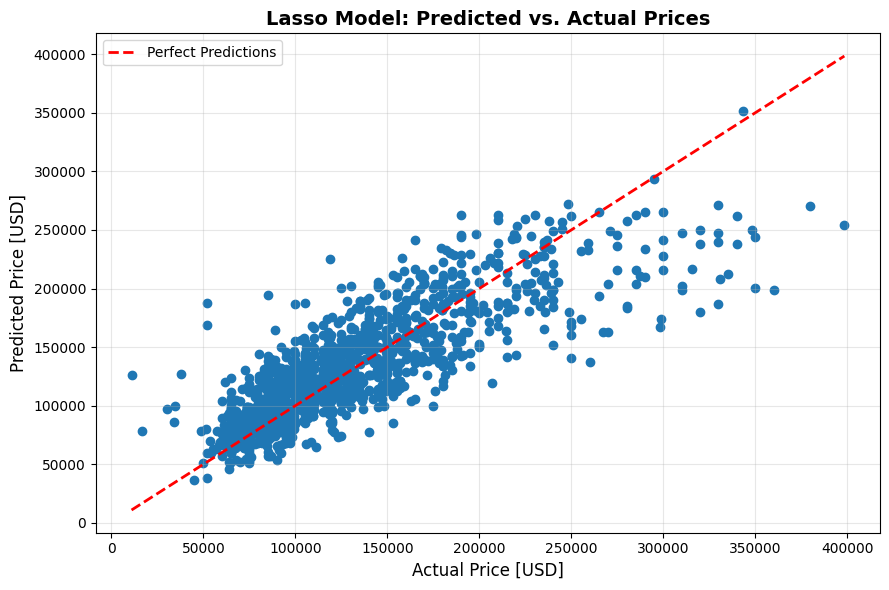

In [22]:
# Predicted vs. Actual plot on Lasso
y_pred_test = model_lasso_cv.predict(X_test)

fig, ax = plt.subplots(figsize=(9,6))

ax.scatter(y_test,y_pred_test)

# Get even ideal line space
ideal_line = np.linspace(start=y_test.min(), stop=y_test.max(),num=100)

ax.plot(ideal_line, ideal_line, label="Perfect Predictions", linewidth=2, color="r", linestyle="--")

ax.set_xlabel("Actual Price [USD]", fontsize=12)
ax.set_ylabel("Predicted Price [USD]", fontsize=12)
ax.set_title("Lasso Model: Predicted vs. Actual Prices", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Residual Analysis

Residual plots reveal patterns that aggregate metrics hide. A model can have an acceptable average RMSE while still making *systematic* errors — consistently underestimating expensive apartments while overestimating cheap ones, for example. Residuals expose these patterns.

Residuals = actual - pred


Scatter plot => Residuals (y) against pred (x)

axhline => y = 0 (Where there are no actual errors, ie the model predicted correctly)

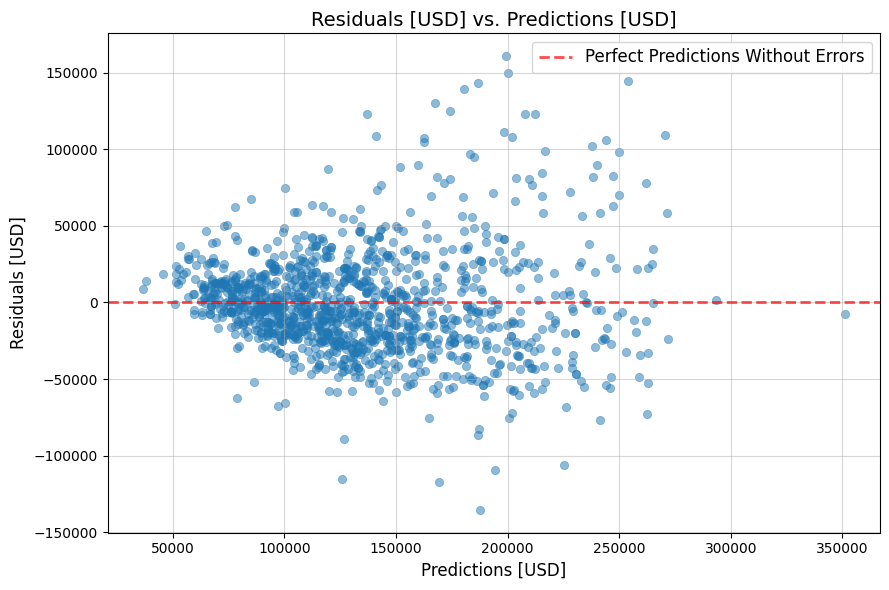

In [23]:
#Calculate the residuals
residuals = y_test - y_pred_test

fig, ax = plt.subplots(figsize=(9,6))

ax.scatter(x=y_pred_test, y=residuals, alpha=0.5, linewidth=0.5)
ax.axhline(y=0,color='r',linewidth=2, alpha=0.7, linestyle='--', label="Perfect Predictions Without Errors")

ax.set_title("Residuals [USD] vs. Predictions [USD]", fontsize=14)
ax.set_xlabel("Predictions [USD]", fontsize=12)
ax.set_ylabel("Residuals [USD]", fontsize=12)
ax.legend(fontsize=12)
ax.grid(visible=True,alpha=0.5)

fig.tight_layout()
fig.show()

In [24]:
# Feature Importance: The Lasso Advantage

coeffs = model_lasso_cv.named_steps['lassocv'].coef_
features = model_lasso_cv.named_steps['onehotencoder'].get_feature_names_out()

coeff_series = pd.Series(data=coeffs,index=features)

non_zero_features = (coeffs != 0).sum()

print(f"LassoCV Total Features: {len(coeff_series)}")
print(f"LassoCV Features: {non_zero_features}")
print(f"\n5 Largest")
print(f"{coeff_series.nlargest().round(2)}")
print(f"\n5 Smallest")
print(f"{coeff_series.nsmallest().round(2)}")

LassoCV Total Features: 59
LassoCV Features: 58

5 Largest
surface_covered_in_m2          40346.18
neighbourhood_Puerto Madero     9793.90
neighbourhood_Palermo           9684.05
lat                             8837.50
neighbourhood_Belgrano          7270.10
dtype: float64

5 Smallest
neighbourhood_Balvanera      -5420.76
neighbourhood_Boca           -4734.04
neighbourhood_Once           -4528.00
neighbourhood_Congreso       -3353.22
neighbourhood_Constitución   -2736.59
dtype: float64


### Lasso's Sparsity: Features Dropped

A key advantage of Lasso over Ridge and Linear Regression is that it identifies which features are not worth including — setting their coefficients exactly to zero. The count of zeroed coefficients is a direct measure of how much Lasso simplified the model relative to what it started with.

In [25]:
zero_features = (coeffs == 0).sum()
percent_eliminated = (zero_features / len(coeff_series)) * 100

print(f"Total Features: {len(coeff_series)}")
print(f"Zero Features: {zero_features}")
print(f"Percent Eliminated: {percent_eliminated:.2f}%")

Total Features: 59
Zero Features: 1
Percent Eliminated: 1.69%


### Visualizing the Top Features

The horizontal bar chart ranks features by absolute coefficient value — the most influential features have the longest bars, whether positive (price premium) or negative (price discount).

> 🧠 **Reading the feature importance chart:**
>
> - **Positive coefficients:** Being in this neighborhood (or having larger surface area) is associated with higher predicted prices
> - **Negative coefficients:** Being in this neighborhood is associated with lower predicted prices relative to the baseline
> - **Near-zero or absent features:** Lasso zeroed them out — the model determined they do not add useful predictive signal after accounting for all other features

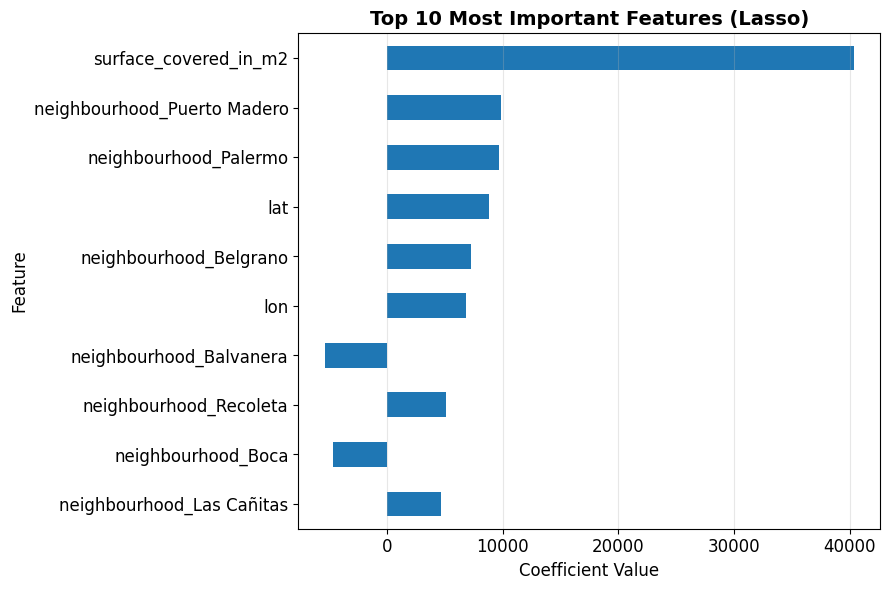

In [26]:
# Plotting the horizontal bar chart
fig, ax = plt.subplots(figsize=(9,6))

# sort the series and plot the bar chart with the features tail top 10 features
coeff_series.sort_values(key=abs).tail(10).plot(kind="barh",ax=ax,fontsize=12,)

ax.set_title("Top 10 Most Important Features (Lasso)", fontsize=14, fontweight='bold')
ax.set_xlabel("Coefficient Value", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.show()

### The Dominant Feature

Among all the features the Lasso model retained, one will have the highest absolute coefficient — the single strongest price signal in the model. Identifying it serves as a sanity check: does the feature the model considers most important make intuitive sense given your knowledge of Buenos Aires real estate?

### 6.5 What the Dominant Feature Tells Us

The feature with the highest absolute coefficient is the single strongest linear price predictor the model found — after controlling for all other features and after Lasso has already eliminated noise features.

**How to interpret it:**

If `top_feature_4` is a neighborhood indicator (e.g., `neighborhood_PuertoMadero`), it means: "After accounting for apartment size and geographic coordinates, being in Puerto Madero is associated with the largest price premium of any factor the model knows about."

If `top_feature_4` is a numeric feature like `surface_covered_in_m2`, it means the model found that size (not neighborhood) is the single strongest predictor — perhaps because the neighborhood effects, while present, are more diffuse across many indicators.

**The sanity check:** Does this make intuitive sense? Puerto Madero is Buenos Aires's most expensive luxury waterfront district. Palermo Soho is a premium trendy neighborhood. If the dominant feature is one of these prestigious neighborhoods, the model has learned something real about the market. If the dominant feature is something unexpected, it may indicate a data artifact worth investigating.

In [27]:
top_feature = coeff_series.idxmax()
top_coeff = coeff_series.max()

print(f"The most influential positive feature is: {top_feature}")
print(f"Its coefficient is: ${top_coeff:,.2f}")

The most influential positive feature is: surface_covered_in_m2
Its coefficient is: $40,346.18


## Final Model Recommendation

A model selection decision is not just a number comparison — it is a structured argument. A professional recommendation states: which model, on what evidence, with what caveats, and for what deployment context.

**The structured recommendation template:**

A rigorous final recommendation answers four questions:
1. **Which model performs best on the primary metric (Test RMSE)?**
2. **Is the difference meaningful** — or are the models statistically equivalent?
3. **Are there secondary criteria** (interpretability, sparsity, robustness) that favor a different choice?
4. **What are the known limitations** that the deployment team must understand?

In [28]:
best_model = results['Test_RMSE'].idxmin()

recommendation = f"""
=================================================================
FINAL MODEL SELECTION REPORT
=================================================================

EXECUTIVE SUMMARY:
Based on comprehensive evaluation, I recommend the {best_model} model
for production deployment.

PERFORMANCE COMPARISON:
- Baseline Test RMSE: ${rmse_baseline_test:,.2f}
- Linear Regression Test RMSE: ${model_OLS_test_rmse:,.2f}
- Ridge (CV-tuned) Test RMSE: ${model_ridge_cv_test_rmse:,.2f}
- Lasso (CV-tuned) Test RMSE: ${model_lasso_cv_test_rmse:,.2f}

GENERALIZATION ANALYSIS:
The {best_model} model shows the best balance between low test error
and minimal generalization gap, indicating it will perform
reliably on new, unseen properties.

INTERPRETABILITY:
The Lasso model eliminated {zero_features} out of
{len(coeff_series)} features ({percent_eliminated:.1f}%),
making it highly interpretable for business stakeholders.

KEY PREDICTORS:
The most influential feature is: {top_feature}

RECOMMENDATION:
I recommend deploying the {best_model} model because:
1. It has the smallest RMSE score.
2. It has a little generalization gap compared with Ridge and Lasso.
3. It is more interpretable as it has fewer features.

=================================================================
"""

print(recommendation)


FINAL MODEL SELECTION REPORT

EXECUTIVE SUMMARY:
Based on comprehensive evaluation, I recommend the Lasso (CV-tuned) model
for production deployment.

PERFORMANCE COMPARISON:
- Baseline Test RMSE: $57,576.13
- Linear Regression Test RMSE: $33,088.37
- Ridge (CV-tuned) Test RMSE: $33,071.27
- Lasso (CV-tuned) Test RMSE: $33,069.18

GENERALIZATION ANALYSIS:
The Lasso (CV-tuned) model shows the best balance between low test error
and minimal generalization gap, indicating it will perform
reliably on new, unseen properties.

INTERPRETABILITY:
The Lasso model eliminated 1 out of
59 features (1.7%),
making it highly interpretable for business stakeholders.

KEY PREDICTORS:
The most influential feature is: surface_covered_in_m2

RECOMMENDATION:
I recommend deploying the Lasso (CV-tuned) model because:
1. It has the smallest RMSE score.
2. It has a little generalization gap compared with Ridge and Lasso.
3. It is more interpretable as it has fewer features.


